In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score , mean_squared_error, mean_absolute_error

In [12]:
df = load_diabetes(as_frame = True).frame

In [13]:
df.shape

(442, 11)

In [14]:
X = df.drop("target" , axis = 1)
y = df["target"]

In [15]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)

In [16]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth = 7 , min_samples_leaf = 20)
model.fit(X_train , y_train)

DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)

In [17]:
from sklearn.metrics import r2_score , mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"MSE train : {mean_squared_error(y_train , y_pred_train)}")
print(f"MSE test : {mean_squared_error(y_test , y_pred_test)}")

print(f"r2 train : {r2_score(y_train , y_pred_train)}")
print(f"r2 test : {r2_score(y_test , y_pred_test)}")

MSE train : 2712.48075111857
MSE test : 3258.996155814711
r2 train : 0.5536038381089772
r2 test : 0.38488055637002505


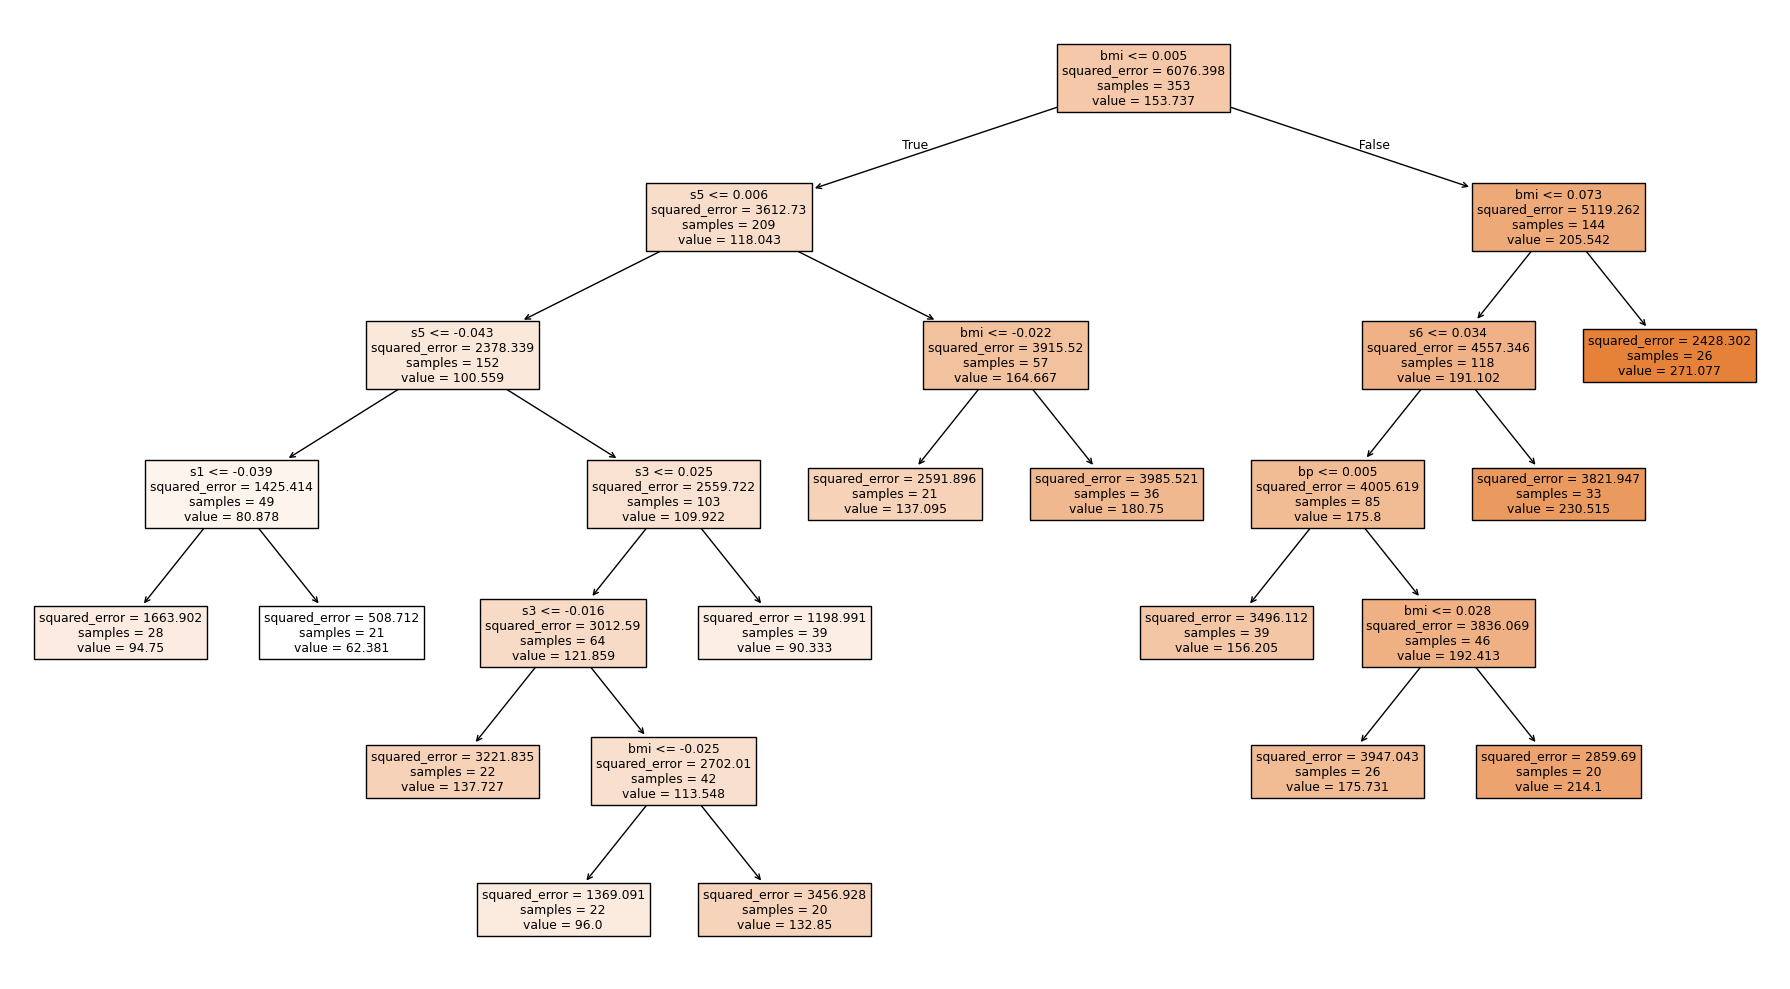

In [18]:
from sklearn.tree import plot_tree

plt.figure(figsize = (18 , 10))

plot_tree(
    model,
    feature_names = X.columns,
    filled = True
)

plt.tight_layout()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=201,
    oob_score=True,
    max_depth=4,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_train_pred = rf.predict(X_train)

print(f"OOB Score : {rf.oob_score_}")
print(f"Test R2 : {r2_score(y_test, y_pred)}")
print(f"Train R2 : {r2_score(y_train, y_train_pred)}")

print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred)}")


OOB Score : 0.44749306722390636
Test R2 : 0.46990880385235845
Train R2 : 0.6627571082918566
Test RMSE : 52.99531675292529
Test MAE : 43.04820363131784
